# Supervised Training TSCP — Eksperimen 3

Melatih **Two Stage CopyNet (TSCP)** (Sequicity, Lei et al. 2018) secara supervised di atas
data hasil `src/preprocessing_v2` (delex word-boundary + vocab hygiene `min_freq=2`).

Semua tahapan (arsitektur, training, evaluasi) ditulis eksplisit di notebook ini.
Alur per turn: `Encode(B_{t-1} R_{t-1} U_t)` -> `Decode B_t` (attn+copy dari X) ->
`Decode R_t` (attn+copy dari B_t, dikondisikan k_t). Loss = CE(B_t) + CE(R_t), teacher forcing.

In [2]:
import sys, os, time, random
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

ROOT = Path.cwd()
while not (ROOT / "data").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
os.chdir(ROOT)

import src.preprocessing_v2 as pp

DEVICE = "cpu"
SEED = 42

def set_seed(seed):
    random.seed(seed)
    torch.manual_seed(seed)

set_seed(SEED)
print("Root:", ROOT, "| Device:", DEVICE, "| Seed:", SEED)

Root: e:\coding bebas\restorant-asistent | Device: cpu | Seed: 42


## 1. Data & Hyperparameter

Hyperparameter mengikuti paper (Section 5.2). Seed tetap membuat inisialisasi bobot dan
urutan shuffle DataLoader deterministik -> reproducible. Data: **train / val / test**.

In [3]:
EMBED_SIZE, HIDDEN_SIZE, KB_SIZE = 50, 50, 3
SL_LR, SL_EPOCHS, SL_BATCH = 0.003, 100, 32
SL_CLIP, SL_PATIENCE, VAL_METRIC_N = 5.0, 10, 150
CKPT_PATH = ROOT / "checkpoints" / "tscp_supervised_v2_best.pt"

data = pp.prepare_data()
word2idx, idx2word, database = data["word2idx"], data["idx2word"], data["database"]
VOCAB = len(word2idx)

train_loader = pp.get_dataloader(data["train"], word2idx, SL_BATCH, shuffle=True)
val_loader = pp.get_dataloader(data["val"], word2idx, SL_BATCH, shuffle=False)
val_metric_samples = data["val"][:VAL_METRIC_N]

Dialog -> train 405 | val 135 | test 136
Sample -> train 1635 | val 553 | test 556
Vocab  -> 613 (min_freq=2, max=800)


## 2. Arsitektur

**Encoder** GRU menghasilkan hidden states H(x). Tiap decoder menggabungkan attention untuk
`P_generate` (Eq. 1-3) dan copy untuk `P_copy` (Eq. 5-8). `combine_copy_probs` menjumlahkan
keduanya (`P = P_gen + P_copy`) di ruang extended vocab `V union X` lewat `scatter_add_`,
sehingga token OOV hanya bisa dicapai lewat copy.

In [4]:
def combine_copy_probs(gen_logits, copy_score, source_indices, ext_size, vocab_size, src_mask=None):
    # softmax bersama atas [vocab ++ posisi source]; prob copy disebar ke index extended-vocab
    if src_mask is not None:
        copy_score = copy_score.masked_fill(~src_mask, -1e10)
    probs = F.softmax(torch.cat([gen_logits, copy_score], dim=1), dim=1)
    p_gen, p_copy = probs[:, :vocab_size], probs[:, vocab_size:]
    ext = torch.zeros((gen_logits.size(0), ext_size), device=gen_logits.device)
    ext[:, :vocab_size] = p_gen
    ext.scatter_add_(1, source_indices, p_copy)
    return torch.log(ext + 1e-12)


class Encoder(nn.Module):
    def __init__(self, vocab, embed, hidden):
        super().__init__()
        self.embedding = nn.Embedding(vocab, embed, padding_idx=0)
        self.gru = nn.GRU(embed, hidden, batch_first=True)

    def forward(self, seq, lengths):
        packed = nn.utils.rnn.pack_padded_sequence(
            self.embedding(seq), lengths.cpu(), batch_first=True, enforce_sorted=False)
        out, hidden = self.gru(packed)
        out, _ = nn.utils.rnn.pad_packed_sequence(out, batch_first=True)
        return out, hidden


class Attn(nn.Module):
    # attention Bahdanau: skor v^T tanh(W1 h_enc + W2 h_dec) -> context (Eq. 1-2)
    def __init__(self, hidden):
        super().__init__()
        self.W1 = nn.Linear(hidden, hidden, bias=False)
        self.W2 = nn.Linear(hidden, hidden, bias=False)
        self.v = nn.Linear(hidden, 1, bias=False)

    def context(self, memory, h_dec, src_mask):
        e = self.v(torch.tanh(self.W1(memory) + self.W2(h_dec).unsqueeze(1))).squeeze(2)
        if src_mask is not None:
            e = e.masked_fill(~src_mask, -1e9)
        return torch.bmm(F.softmax(e, dim=1).unsqueeze(1), memory).squeeze(1)


class DecoderStage1(nn.Module):
    # generate belief span B_t: attention + copy dari input X
    def __init__(self, vocab, embed, hidden):
        super().__init__()
        self.vocab_size = vocab
        self.embedding = nn.Embedding(vocab, embed, padding_idx=0)
        self.gru = nn.GRU(embed, hidden, batch_first=True)
        self.attn = Attn(hidden)
        self.output_proj = nn.Linear(hidden * 2, vocab)
        self.W_copy = nn.Linear(hidden, hidden, bias=False)

    def step(self, dec_input, hidden, memory, src_mask=None):
        out, hidden = self.gru(self.embedding(dec_input), hidden)
        h = out.squeeze(1)
        ctx = self.attn.context(memory, h, src_mask)
        gen = self.output_proj(torch.cat([ctx, h], dim=1))
        copy = torch.bmm(torch.sigmoid(self.W_copy(memory)), h.unsqueeze(2)).squeeze(2)
        return gen, copy, hidden

    def decode(self, seq, hidden, memory, ext_source, ext_size):
        mask = ext_source != 0
        outs = []
        for t in range(seq.size(1)):
            gen, copy, hidden = self.step(seq[:, t:t + 1], hidden, memory, mask)
            outs.append(combine_copy_probs(gen, copy, ext_source, ext_size, self.vocab_size, mask))
        return torch.stack(outs, dim=1), hidden


class DecoderStage2(nn.Module):
    # generate response R_t: init hidden dari Stage 1, attn+copy dari B_t, k_t di-concat (Eq. 7-9)
    def __init__(self, vocab, embed, hidden, kb):
        super().__init__()
        self.vocab_size = vocab
        self.embedding = nn.Embedding(vocab, embed, padding_idx=0)
        self.gru = nn.GRU(embed + kb, hidden, batch_first=True)
        self.attn = Attn(hidden)
        self.output_proj = nn.Linear(hidden * 2, vocab)
        self.W_copy = nn.Linear(hidden, hidden, bias=False)

    def step(self, dec_input, hidden, memory, kt, src_mask=None):
        gin = torch.cat([self.embedding(dec_input), kt.unsqueeze(1)], dim=2)
        out, hidden = self.gru(gin, hidden)
        h = out.squeeze(1)
        ctx = self.attn.context(memory, h, src_mask)
        gen = self.output_proj(torch.cat([ctx, h], dim=1))
        copy = torch.bmm(torch.sigmoid(self.W_copy(memory)), h.unsqueeze(2)).squeeze(2)
        return gen, copy, hidden

    def decode(self, seq, hidden, memory, kt, ext_source, ext_size):
        mask = ext_source != 0
        outs = []
        for t in range(seq.size(1)):
            gen, copy, hidden = self.step(seq[:, t:t + 1], hidden, memory, kt, mask)
            outs.append(combine_copy_probs(gen, copy, ext_source, ext_size, self.vocab_size, mask))
        return torch.stack(outs, dim=1), hidden

## 3. Model TSCP & Loss

`build_copy_map` membentuk index extended-vocab per-sample (OOV -> vocab_size + offset);
`target_to_ext` memetakan token target ke ruang yang sama sehingga target OOV hanya bisa
dicapai lewat copy. Loss = cross-entropy pada extended vocab, mengabaikan padding.

In [5]:
def build_copy_map(tokens, word2idx):
    vs = len(word2idx)
    oov, oov_map, ext = [], {}, []
    for t in tokens:
        if t in word2idx:
            ext.append(word2idx[t])
        else:
            if t not in oov_map:
                oov_map[t] = vs + len(oov)
                oov.append(t)
            ext.append(oov_map[t])
    return ext, oov_map, vs + len(oov)


def target_to_ext(tokens, word2idx, oov_map):
    unk = word2idx[pp.UNK_TOKEN]
    return [word2idx[t] if t in word2idx else oov_map.get(t, unk) for t in tokens]


def pad_rows(rows, width, device):
    return torch.tensor([r + [0] * (width - len(r)) for r in rows], dtype=torch.long, device=device)


class TSCP(nn.Module):
    def __init__(self, vocab, embed=EMBED_SIZE, hidden=HIDDEN_SIZE, kb=KB_SIZE):
        super().__init__()
        self.vocab_size = vocab
        self.encoder = Encoder(vocab, embed, hidden)
        self.decoder1 = DecoderStage1(vocab, embed, hidden)
        self.decoder2 = DecoderStage2(vocab, embed, hidden, kb)

    @staticmethod
    def loss_fn(logp, target, ext_size):
        lp, tg = logp.reshape(-1, ext_size), target.reshape(-1)
        mask = tg.ne(0)
        nll = -lp.gather(1, tg.clamp(0, ext_size - 1).unsqueeze(1)).squeeze(1) * mask.float()
        return nll.sum() / mask.float().sum().clamp(min=1)

    def forward(self, batch, word2idx, kt):
        dev = batch["input"].device
        enc_out, enc_h = self.encoder(batch["input"], batch["input_lengths"])
        B = batch["input"].size(0)
        Lx, Lb, Lr = batch["input"].size(1), batch["bspan_in"].size(1), batch["resp_in"].size(1)

        src_rows, btgt_rows, ext1 = [], [], self.vocab_size
        for i in range(B):
            ext, omap, esz = build_copy_map(batch["input_tokens"][i], word2idx)
            ext1 = max(ext1, esz)
            src_rows.append(ext)
            btgt_rows.append(target_to_ext(batch["bspan_tgt_tokens"][i], word2idx, omap))
        bspan_logp, bspan_hidden = self.decoder1.decode(
            batch["bspan_in"], enc_h, enc_out, pad_rows(src_rows, Lx, dev), ext1)
        loss_b = self.loss_fn(bspan_logp, pad_rows(btgt_rows, Lb, dev), ext1)

        bspan_out, _ = self.decoder1.gru(self.decoder1.embedding(batch["bspan_in"]), enc_h)
        bsrc_rows, rtgt_rows, ext2 = [], [], self.vocab_size
        for i in range(B):
            ext, omap, esz = build_copy_map(batch["bspan_in_tokens"][i], word2idx)
            ext2 = max(ext2, esz)
            bsrc_rows.append(ext)
            rtgt_rows.append(target_to_ext(batch["resp_tgt_tokens"][i], word2idx, omap))
        resp_logp, _ = self.decoder2.decode(
            batch["resp_in"], bspan_hidden, bspan_out, kt, pad_rows(bsrc_rows, Lb, dev), ext2)
        loss_r = self.loss_fn(resp_logp, pad_rows(rtgt_rows, Lr, dev), ext2)
        return loss_b + loss_r, loss_b, loss_r

## 4. Evaluasi (greedy decode + metrik)

Inference greedy: encode -> decode B_t -> KB search (k_t) -> decode R_t. Metrik mengikuti
paper: **BLEU** (kualitas bahasa), **Entity Match** (informable B_t prediksi vs gold),
**Success F1** (kelengkapan requestable slot pada response).

In [6]:
SLOT_PH = {"address": "address_slot", "phone": "phone_slot", "postcode": "postcode_slot",
           "food": "food_slot", "area": "area_slot", "pricerange": "pricerange_slot", "name": "name_slot"}


@torch.no_grad()
def greedy(decoder, hidden, memory, src, ext_size, inv_oov, kt=None, max_len=50):
    mask = src != 0
    di = torch.tensor([[word2idx[pp.SOS_TOKEN]]], device=DEVICE)
    out = []
    for _ in range(max_len):
        if kt is None:
            gen, copy, hidden = decoder.step(di, hidden, memory, mask)
        else:
            gen, copy, hidden = decoder.step(di, hidden, memory, kt, mask)
        idx = combine_copy_probs(gen, copy, src, ext_size, VOCAB, mask).argmax(1).item()
        if idx == word2idx[pp.EOS_TOKEN]:
            break
        out.append(idx2word[idx] if idx < VOCAB else inv_oov.get(idx, pp.UNK_TOKEN))
        di = torch.tensor([[idx if idx < VOCAB else word2idx[pp.UNK_TOKEN]]], device=DEVICE)
    return out


@torch.no_grad()
def generate(model, sample):
    model.eval()
    it = pp.tokenize(sample["input"])
    ids = torch.tensor([pp.tokens_to_ids(it, word2idx)], device=DEVICE)
    enc_out, enc_h = model.encoder(ids, torch.tensor([len(it)]))
    ext, omap, esz = build_copy_map(it, word2idx)
    pb = greedy(model.decoder1, enc_h, enc_out, torch.tensor([ext], device=DEVICE), esz,
                {v: k for k, v in omap.items()})
    pb_text = " ".join(pb)

    bspan_tokens = [pp.SOS_TOKEN] + pb
    bids = torch.tensor([pp.tokens_to_ids(bspan_tokens, word2idx)], device=DEVICE)
    bspan_out, bspan_h = model.decoder1.gru(model.decoder1.embedding(bids), enc_h)
    bext, bomap, besz = build_copy_map(bspan_tokens, word2idx)
    kt = pp.get_kt_from_bspan(pb_text, database).unsqueeze(0).to(DEVICE)
    pr = greedy(model.decoder2, bspan_h, bspan_out, torch.tensor([bext], device=DEVICE), besz,
                {v: k for k, v in bomap.items()}, kt=kt)
    return pb_text, " ".join(pr)


def entity_match(pred_b, gold_b):
    ok = sum(set(v.lower() for v in pp.parse_bspan(p)[0]) == set(v.lower() for v in pp.parse_bspan(g)[0])
             for p, g in zip(pred_b, gold_b))
    return ok / max(len(gold_b), 1)


def success_f1(pred_r, gold_b):
    precs, recs = [], []
    for resp, g in zip(pred_r, gold_b):
        expected = {SLOT_PH[r.lower()] for r in pp.parse_bspan(g)[1] if r.lower() in SLOT_PH}
        if not expected:
            continue
        low = resp.lower()
        found = {p for p in expected if p in low}
        present = {p for p in SLOT_PH.values() if p in low}
        recs.append(len(found) / len(expected))
        precs.append(len(found & present) / len(present) if present else 0.0)
    if not precs:
        return 0.0
    P, R = sum(precs) / len(precs), sum(recs) / len(recs)
    return 2 * P * R / (P + R) if P + R else 0.0


def evaluate(model, samples, show=0):
    pred_b, gold_b, pred_r, refs, hyps = [], [], [], [], []
    for i, s in enumerate(samples):
        pb, pr = generate(model, s)
        pred_b.append(pb); gold_b.append(s["target_bspan"]); pred_r.append(pr)
        refs.append([pp.tokenize(s["target_response"])]); hyps.append(pp.tokenize(pr))
        if i < show:
            print(f"[{i}] gold B: {s['target_bspan']}\n    pred B: {pb}\n    pred R: {pr}")
    pairs = [(r, h) for r, h in zip(refs, hyps) if h]
    bleu = corpus_bleu([r for r, _ in pairs], [h for _, h in pairs],
                       smoothing_function=SmoothingFunction().method1) if pairs else 0.0
    return {"BLEU": bleu, "EntityMatch": entity_match(pred_b, gold_b), "SuccessF1": success_f1(pred_r, gold_b)}

## 5. Loop Training

Satu optimizer & satu backward untuk seluruh model. Tiap epoch menampilkan **train loss,
val loss, dan metrik val** (BLEU / Entity Match / Success F1). Early stopping berdasar val
loss; checkpoint terbaik disimpan.

In [7]:
def kt_batch(batch):
    return torch.stack([pp.get_kt_from_bspan(t, database) for t in batch["bspan_text"]])


def to_device(batch):
    for k in ("input", "bspan_in", "resp_in"):
        batch[k] = batch[k].to(DEVICE)
    return batch


def run_epoch(model, loader, opt=None):
    training = opt is not None
    model.train() if training else model.eval()
    tot = 0.0
    n = 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for batch in loader:
            batch = to_device(batch)
            kt = kt_batch(batch).to(DEVICE)
            loss, lb, lr = model(batch, word2idx, kt)
            if training:
                opt.zero_grad()
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), SL_CLIP)
                opt.step()
            tot += loss.item(); n += 1
    return tot / n

In [8]:
set_seed(SEED)
model = TSCP(VOCAB).to(DEVICE)
opt = torch.optim.Adam(model.parameters(), lr=SL_LR)
print(f"Vocab {VOCAB} | Params {sum(p.numel() for p in model.parameters()):,}")

CKPT_PATH.parent.mkdir(exist_ok=True)
hist = {"train_loss": [], "val_loss": [], "bleu": [], "em": [], "f1": []}
best, patience = float("inf"), 0
for epoch in range(1, SL_EPOCHS + 1):
    t0 = time.time()
    tr_loss = run_epoch(model, train_loader, opt)
    val_loss = run_epoch(model, val_loader)
    m = evaluate(model, val_metric_samples)
    hist["train_loss"].append(tr_loss); hist["val_loss"].append(val_loss)
    hist["bleu"].append(m["BLEU"]); hist["em"].append(m["EntityMatch"]); hist["f1"].append(m["SuccessF1"])
    print(f"Epoch {epoch:3d} | train {tr_loss:.4f} | val {val_loss:.4f} | "
          f"BLEU {m['BLEU']:.4f} | EM {m['EntityMatch']:.4f} | F1 {m['SuccessF1']:.4f} | {time.time()-t0:.1f}s")
    if val_loss < best:
        best, patience = val_loss, 0
        torch.save({"model_state_dict": model.state_dict(), "word2idx": word2idx,
                    "vocab_size": VOCAB, "epoch": epoch, "val_loss": best}, CKPT_PATH)
        print(f"  saved (val {best:.4f})")
    else:
        patience += 1
        if patience >= SL_PATIENCE:
            print(f"Early stopping @ epoch {epoch}")
            break
print("Best val loss:", round(best, 4))

Vocab 613 | Params 277,226
Epoch   1 | train 6.2614 | val 3.5920 | BLEU 0.0083 | EM 0.6800 | F1 0.4162 | 8.7s
  saved (val 3.5920)
Epoch   2 | train 2.8971 | val 2.4471 | BLEU 0.1454 | EM 0.7800 | F1 0.4507 | 9.1s
  saved (val 2.4471)
Epoch   3 | train 2.1866 | val 2.0169 | BLEU 0.1340 | EM 0.8067 | F1 0.3721 | 9.0s
  saved (val 2.0169)
Epoch   4 | train 1.8635 | val 1.8172 | BLEU 0.1803 | EM 0.8267 | F1 0.4467 | 9.2s
  saved (val 1.8172)
Epoch   5 | train 1.6817 | val 1.7062 | BLEU 0.2079 | EM 0.8533 | F1 0.6410 | 8.9s
  saved (val 1.7062)
Epoch   6 | train 1.5324 | val 1.6482 | BLEU 0.2097 | EM 0.8333 | F1 0.5106 | 9.4s
  saved (val 1.6482)
Epoch   7 | train 1.4357 | val 1.5977 | BLEU 0.1670 | EM 0.8467 | F1 0.4905 | 9.0s
  saved (val 1.5977)
Epoch   8 | train 1.3643 | val 1.5657 | BLEU 0.1658 | EM 0.8933 | F1 0.6346 | 8.7s
  saved (val 1.5657)
Epoch   9 | train 1.2883 | val 1.5405 | BLEU 0.1784 | EM 0.8867 | F1 0.6871 | 8.7s
  saved (val 1.5405)
Epoch  10 | train 1.2353 | val 1.5363

## 6. Visualisasi

Kiri: kurva loss (train vs val). Kanan: metrik text-generation di val per epoch
(BLEU / Entity Match / Success F1) sebagai pembanding perkembangan kualitas generasi.

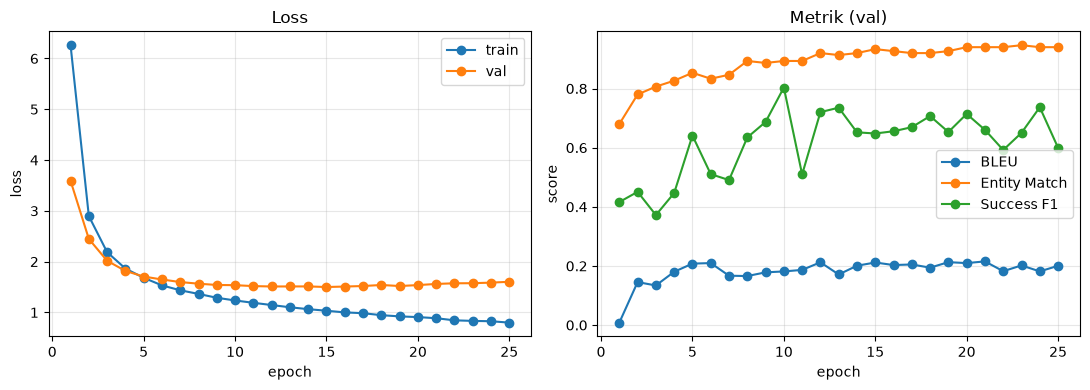

In [9]:
ep = range(1, len(hist["train_loss"]) + 1)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(ep, hist["train_loss"], marker="o", label="train")
ax[0].plot(ep, hist["val_loss"], marker="o", label="val")
ax[0].set_title("Loss"); ax[0].set_xlabel("epoch"); ax[0].set_ylabel("loss")
ax[0].legend(); ax[0].grid(alpha=0.3)
ax[1].plot(ep, hist["bleu"], marker="o", label="BLEU")
ax[1].plot(ep, hist["em"], marker="o", label="Entity Match")
ax[1].plot(ep, hist["f1"], marker="o", label="Success F1")
ax[1].set_title("Metrik (val)"); ax[1].set_xlabel("epoch"); ax[1].set_ylabel("score")
ax[1].legend(); ax[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Evaluasi Test

Muat checkpoint terbaik, evaluasi pada **test set** dengan menampilkan beberapa contoh.

In [10]:
ckpt = torch.load(CKPT_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state_dict"])
res = evaluate(model, data["test"], show=5)
print(f"\nTEST -> BLEU {res['BLEU']:.4f} | Entity Match {res['EntityMatch']:.4f} | Success F1 {res['SuccessF1']:.4f}")

[0] gold B: <Inf> cuban ; moderate </Inf> <Req>  </Req>
    pred B: <Inf> cuban ; moderate </Inf> <Req> </Req>
    pred R: there are no cuban restaurants in the AREA_SLOT part of town . would you like to try something else ?
[1] gold B: <Inf> british ; moderate </Inf> <Req>  </Req>
    pred B: <Inf> british ; moderate </Inf> <Req> </Req>
    pred R: there are two restaurants that serve FOOD_SLOT food . would you like their address ?
[2] gold B: <Inf> british ; moderate </Inf> <Req> phone </Req>
    pred B: <Inf> british ; moderate </Inf> <Req> phone </Req>
    pred R: the phone number for NAME_SLOT is PHONE_SLOT .
[3] gold B: <Inf> british ; moderate </Inf> <Req>  </Req>
    pred B: <Inf> british ; moderate </Inf> <Req> </Req>
    pred R: thank you , goodbye .
[4] gold B: <Inf> british ; moderate </Inf> <Req>  </Req>
    pred B: <Inf> british ; moderate </Inf> <Req> </Req>
    pred R: thank you , goodbye .

TEST -> BLEU 0.2181 | Entity Match 0.9245 | Success F1 0.6319


## 8. Catatan

Checkpoint `tscp_supervised_v2_best.pt` menyimpan `word2idx` -> siap dipakai RL fine-tuning
(eksp2). Konvensi belief-span `<Inf>`/`<Req>` (kapital, ikut paper), vocab 613.